_Neural Data Science_

Lecturer: Dr. Jan Lause, Prof. Dr. Philipp Berens

Tutors: Jonas Beck, Fabio Seel, Julius Würzler

Summer term 2025

Student names: <span style='background: yellow'>*FILL IN YOUR NAMES HERE* </span>

LLM Disclaimer: <span style='background: yellow'>*Did you use an LLM to solve this exercise? If yes, which one and where did you use it? [Copilot, Claude, ChatGPT, etc.]* </span>

# Project 3: Single-cell data analysis.

In [ ]:
# RUN THIS
#!pip install umap-learn hdbscan scanpy

In [1]:
%matplotlib notebook
%matplotlib inline
    
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import string

import scipy as sp
from scipy import sparse
import sklearn

## add your packages ##
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from sklearn.manifold import TSNE, trustworthiness as sk_trustworthiness
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import adjusted_mutual_info_score, silhouette_score
import umap
import hdbscan
import warnings

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder

import scanpy as sc
from anndata import AnnData

import time
import pickle
import memory_profiler

%load_ext memory_profiler

from pathlib import Path

In [2]:
import black
import jupyter_black

jupyter_black.load(line_length=79)

In [3]:
variables_path = Path("../results/variables")
figures_path = Path("../results/figures")
data_path = Path("../data")

In [4]:
plt.style.use("../matplotlib_style.txt")

In [5]:
np.random.seed(42)

## Project and data description

In this project, we are going to work with the typical methods and pipelines used in single-cell data analysis and get some hands-on experience with the techniques used in the field. For that, we will be using Patch-seq multimodal data from cortical neurons in mice, from Scala et al. 2021 (https://www.nature.com/articles/s41586-020-2907-3#Sec7). From the different data modalities they used, we will focus on transcriptomics and electrophysiological data. 

In a real-world scenario, single cell data rarely comes with any "ground truth" labels. Often, the goal of researchers after measuring cells is to precisely classify them, grouping them into families or assigning them cell types based on the recorded features. This is normally done using usupervised methods, such as clustering methods.

However, the single-cell data that we are using in this project has some cell types assigned to each cell. These are not "ground truth" type annotations, but were one of the results from the original Scala et al. work. Still, we are going to use those annotations for validation (despite them not really being ground truth) to sanity-check some of our analyses, such as visualizations, clustering, etc. We will mainly work with cell types (`rna_types`, 77 unique types) and cell families (`rna_families`, 9 unique families).

From the transcriptomics mRNA counts, we will only work with the exon counts for simplicity. Some of the electrophysiological features are not high-quality recordings, therefore we will also filter them out.

## Import data

### Meta data

In [6]:
# META DATA

meta = pd.read_csv(data_path / "m1_patchseq_meta_data.csv", sep="\t")

cells = meta["Cell"].values

layers = meta["Targeted layer"].values.astype("str")
cre = meta["Cre"].values
yields = meta["Yield (pg/µl)"].values
yields[yields == "?"] = np.nan
yields = yields.astype("float")
depth = meta["Soma depth (µm)"].values
depth[depth == "Slice Lost"] = np.nan
depth = depth.astype(float)
thickness = meta["Cortical thickness (µm)"].values
thickness[thickness == 0] = np.nan
thickness = thickness.astype(float)
traced = meta["Traced"].values == "y"
exclude = meta["Exclusion reasons"].values.astype(str)
exclude[exclude == "nan"] = ""

mice_names = meta["Mouse"].values
mice_ages = meta["Mouse age"].values
mice_cres = np.array(
    [
        c if c[-1] != "+" and c[-1] != "-" else c[:-1]
        for c in meta["Cre"].values
    ]
)
mice_ages = dict(zip(mice_names, mice_ages))
mice_cres = dict(zip(mice_names, mice_cres))

print("Number of cells with measured depth:    ", np.sum(~np.isnan(depth)))
print("Number of cells with measured thickness:", np.sum(~np.isnan(thickness)))
print("Number of reconstructed cells:          ", np.sum(traced))

sliceids = meta["Slice"].values
a, b = np.unique(sliceids, return_counts=True)
assert np.all(b <= 2)
print("Number of slices with two cells:        ", np.sum(b == 2))

# Some consistency checks
assert np.all(
    [
        np.unique(meta["Date"].values[mice_names == m]).size == 1
        for m in mice_names
    ]
)
assert np.all(
    [
        np.unique(meta["Mouse age"].values[mice_names == m]).size == 1
        for m in mice_names
    ]
)
assert np.all(
    [
        np.unique(meta["Mouse gender"].values[mice_names == m]).size == 1
        for m in mice_names
    ]
)
assert np.all(
    [
        np.unique(meta["Mouse genotype"].values[mice_names == m]).size == 1
        for m in mice_names
    ]
)
assert np.all(
    [
        np.unique(meta["Mouse"].values[sliceids == s]).size == 1
        for s in sliceids
    ]
)

Number of cells with measured depth:     1284
Number of cells with measured thickness: 1284
Number of reconstructed cells:           646
Number of slices with two cells:         69


In [7]:
meta.columns

Index(['Number', 'Cell', 'Slice', 'Date', 'Sample', 'Mouse',
       'Mouse date of birth', 'Mouse age', 'Mouse gender', 'Mouse genotype',
       'Targeted layer', 'Inferred layer', 'Cre', 'Exon reads', 'Intron reads',
       'Intergenic reads', 'Sequencing batch', 'Number of genes detected',
       'RNA family', 'RNA type', 'RNA type confidence', 'RNA type top-3',
       'ALM/VISp top-3', 'Length (bp)', 'Yield (pg/µl)', 'User',
       'Hold Time (min)', 'Soma depth (µm)', 'Soma depth (4x)',
       'Cortical thickness (4x)', 'Cortical thickness (µm)', 'Traced',
       'Exclusion reasons'],
      dtype='object')

### "Ground truth labels"

In [8]:
# filter out low quality cells in term of RNA
print(
    "There are",
    np.sum(meta["RNA family"] == "low quality"),
    "cells with low quality RNA recordings.",
)
exclude_low_quality = meta["RNA family"] != "low quality"

There are 97 cells with low quality RNA recordings.


In [9]:
rna_family = meta["RNA family"][exclude_low_quality]
rna_type = meta["RNA type"][exclude_low_quality]

In [10]:
print(len(np.unique(rna_family)))
print(len(np.unique(rna_type)))

9
77


In [11]:
pickle_in = open(data_path / "dict_rna_type_colors.pkl", "rb")
dict_rna_type_colors = pickle.load(pickle_in)

In [12]:
rna_type_colors = np.vectorize(dict_rna_type_colors.get)(rna_type)

### Transcriptomic data

In [13]:
meta[["Cell", "Exon reads"]]

,Cell,Exon reads
0,20171204_sample_2,10315633
1,20171204_sample_4,5272324
2,20171204_sample_5,18172944
3,20171204_sample_6,6226321
4,20171207_sample_1,3786954
...,...,...
1324,20200225_sample_2,495650
1325,20200225_sample_5,2843801
1326,20200316_sample_1,395135
1327,20200316_sample_2,470005


In [14]:
# READ COUNTS
data_exons = pd.read_csv(
    data_path / "m1_patchseq_exon_counts.csv.gz", na_filter=False, index_col=0
)

assert all(cells == data_exons.columns)
genes = np.array(data_exons.index)

# filter out low quality cells in term of rna family
exonCounts = data_exons.values.transpose()[exclude_low_quality]
print("Count matrix shape (exon):  ", exonCounts.shape)

Count matrix shape (exon):   (1232, 42466)


In [15]:
# GENE LENGTH

data = pd.read_csv(data_path / "gene_lengths.txt")
assert all(data["GeneID"] == genes)
exonLengths = data["exon_bp"].values

### Electrophysiological features

In [16]:
# EPHYS DATA

ephysData = pd.read_csv(data_path / "m1_patchseq_ephys_features.csv")
ephysNames = np.array(ephysData.columns[1:]).astype(str)
ephysCells = ephysData["cell id"].values
ephysData = ephysData.values[:, 1:].astype("float")
names2ephys = dict(zip(ephysCells, ephysData))
ephysData = np.array(
    [
        names2ephys[c] if c in names2ephys else ephysData[0] * np.nan
        for c in cells
    ]
)

print("Number of cells with ephys data:", np.sum(np.isin(cells, ephysCells)))

assert np.sum(~np.isin(ephysCells, cells)) == 0

Number of cells with ephys data: 1328


In [17]:
# Filtering ephys data

features_exclude = [
    "Afterdepolarization (mV)",
    "AP Fano factor",
    "ISI Fano factor",
    "Latency @ +20pA current (ms)",
    "Wildness",
    "Spike frequency adaptation",
    "Sag area (mV*s)",
    "Sag time (s)",
    "Burstiness",
    "AP amplitude average adaptation index",
    "ISI average adaptation index",
    "Rebound number of APs",
]
features_log = [
    "AP coefficient of variation",
    "ISI coefficient of variation",
    "ISI adaptation index",
    "Latency (ms)",
]

X = ephysData[exclude_low_quality]
print(X.shape)
for e in features_log:
    X[:, ephysNames == e] = np.log(X[:, ephysNames == e])
X = X[:, ~np.isin(ephysNames, features_exclude)]

keepcells = ~np.isnan(np.sum(X, axis=1))
X = X[keepcells, :]
print(X.shape)

X = X - X.mean(axis=0)
ephysData_filtered = X / X.std(axis=0)

(1232, 29)
(1224, 17)


In [18]:
np.sum(np.isnan(ephysData_filtered))

np.int64(0)

# Research questions to investigate

## 1 - Inspect the data by computing key statistics
For RNA counts, you can compute and plot statistics, e.g. total counts per cell, number of expressed genes per cell, mean count per gene, variance per gene, mean-variance relationship... See https://www.embopress.org/doi/full/10.15252/msb.20188746 for common quality control statistics. Keep in mind that the RNA data in this project is read counts, not UMI counts, so it is not supposed to follow a Poisson distribution. To get an idea of the technical noise in the data, you can plot count distributions of single genes within cell types (like in the lecture). 

Similarly, you can compute and plot statistics over the electrophyiological data. Also, investigate the distribution of "ground truth" labels. Comment about other relevant metadata, and think if you can use it as some external validation for other analyses. If you do use other metadata throughout the project, explain why and what you get out of it. Take into account that certain features may not be very informative for our purposes (e.g. mouse age), so only choose features that provide you with useful information in this context. If you want to get additional information about the metadata, have a look at the extended data section in the original publication (e.g., cre-lines in Figure 1c in the extended data).

### 1.1 - Transcriptomics

C:\Users\pdvsupport\AppData\Local\Temp\ipykernel_9240\1685462249.py:64: UserWarning: The figure layout has changed to tight
  plt.tight_layout(); plt.show()


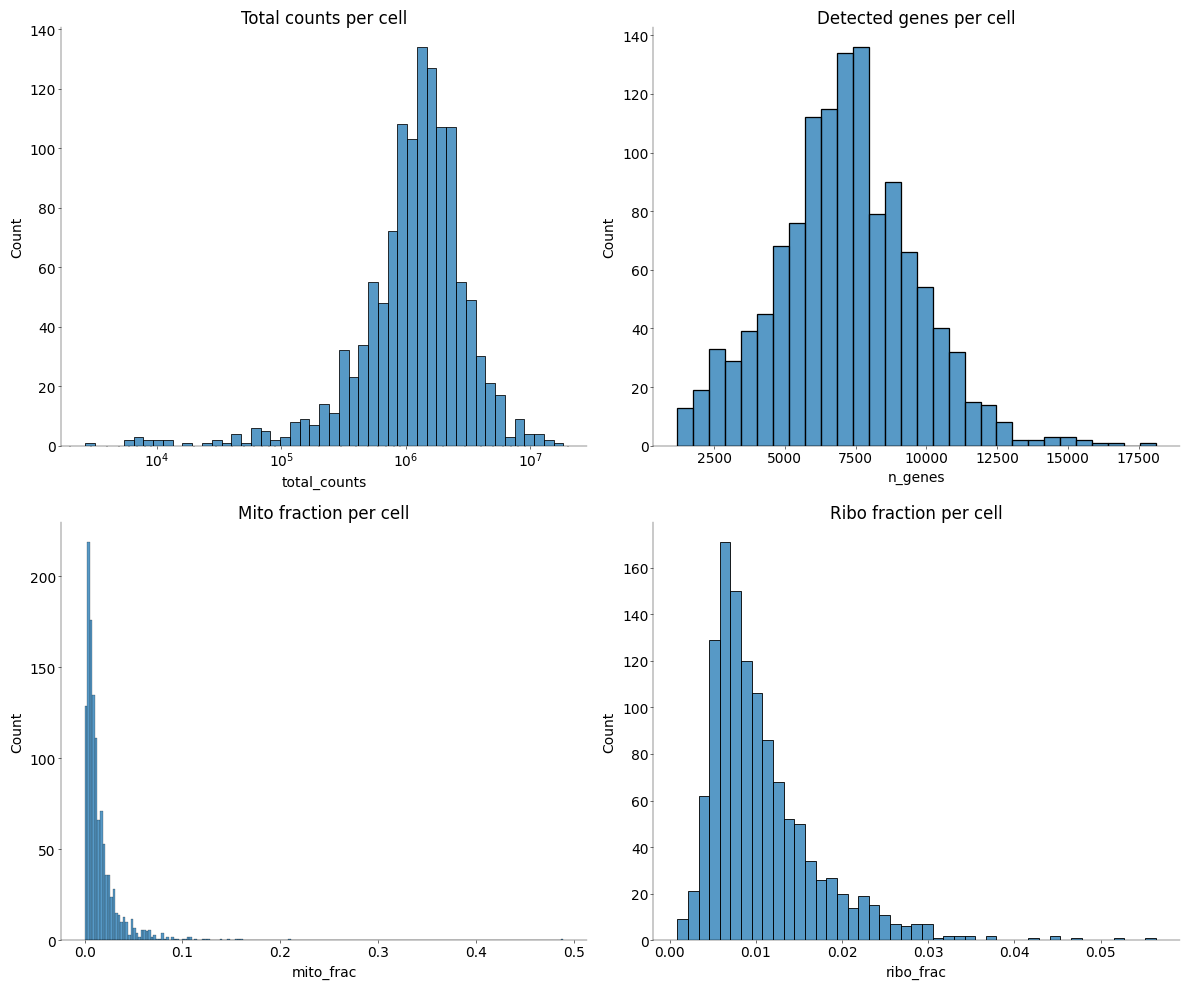

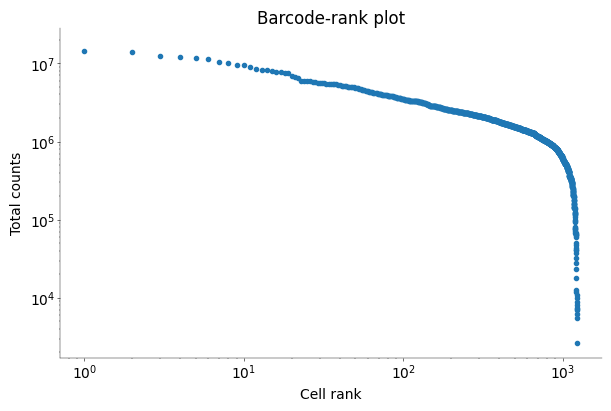

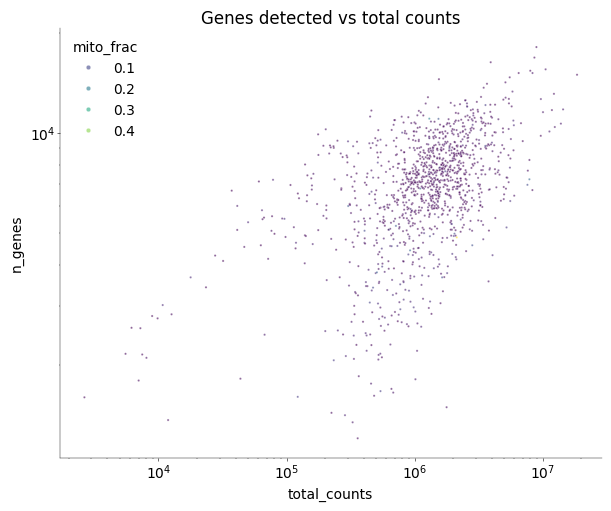

C:\Users\pdvsupport\AppData\Local\Temp\ipykernel_9240\1685462249.py:89: UserWarning: The figure layout has changed to tight
  plt.tight_layout(); plt.show()


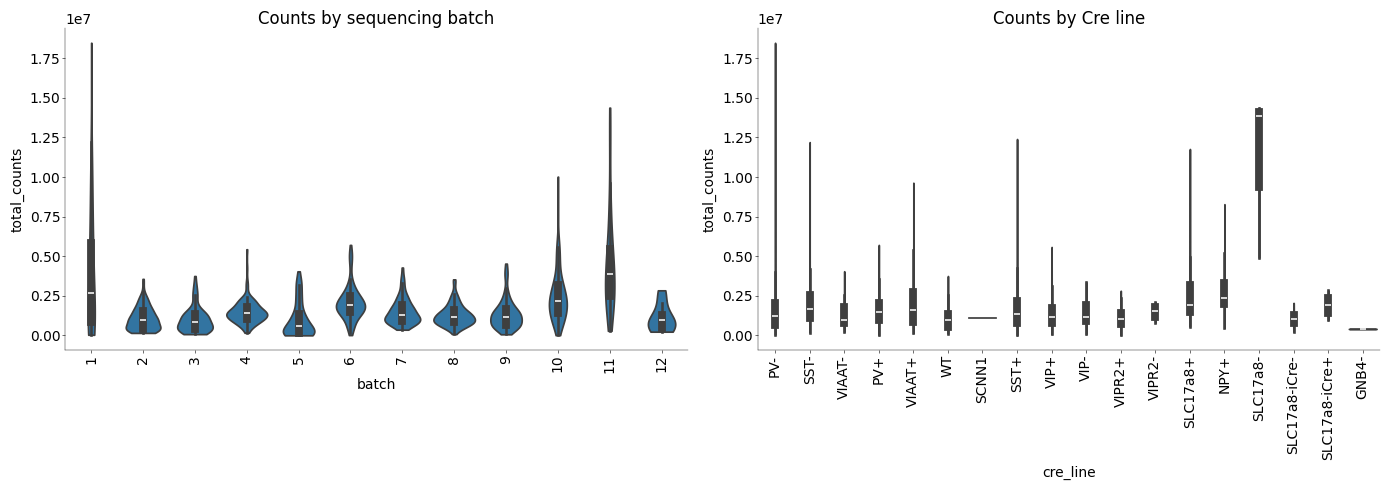

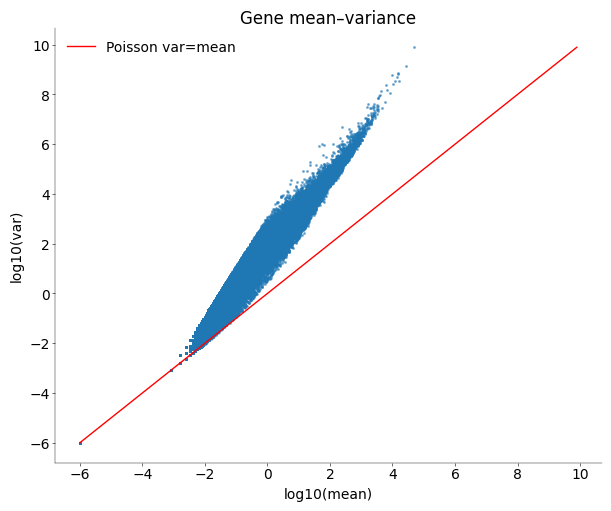

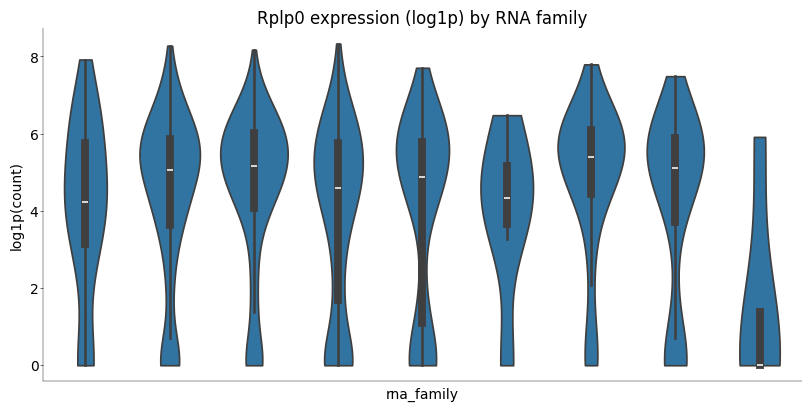

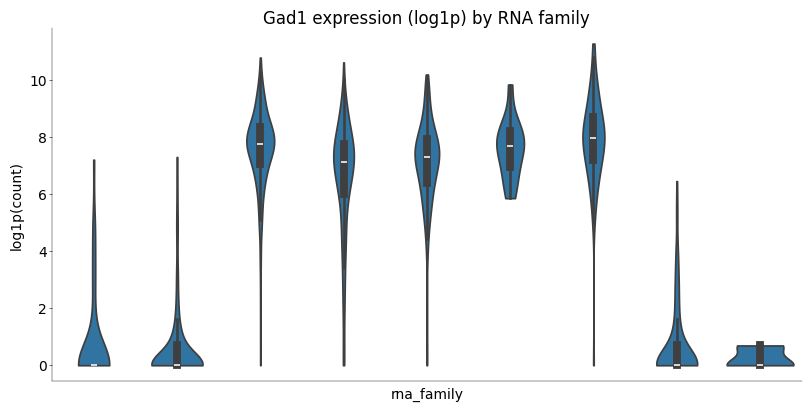

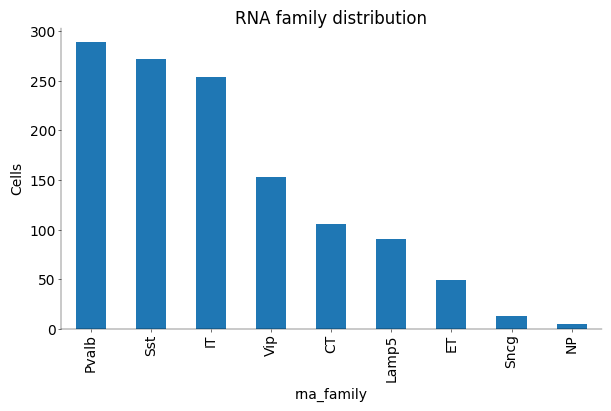

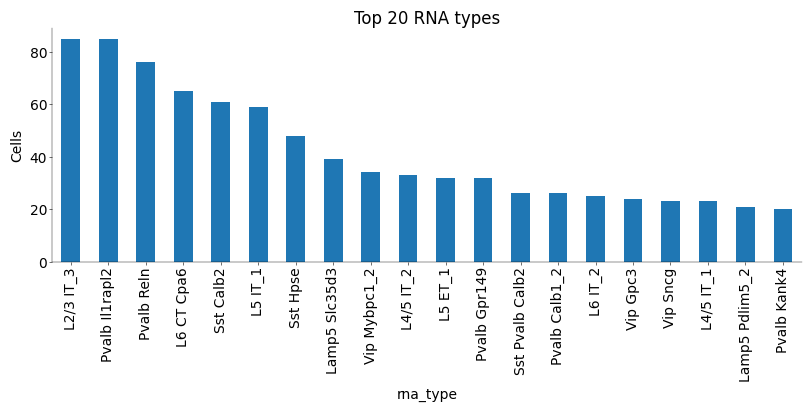

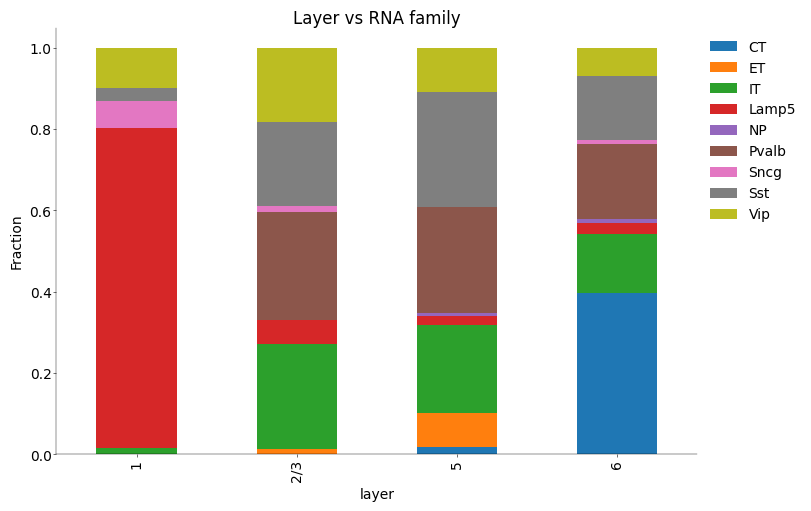

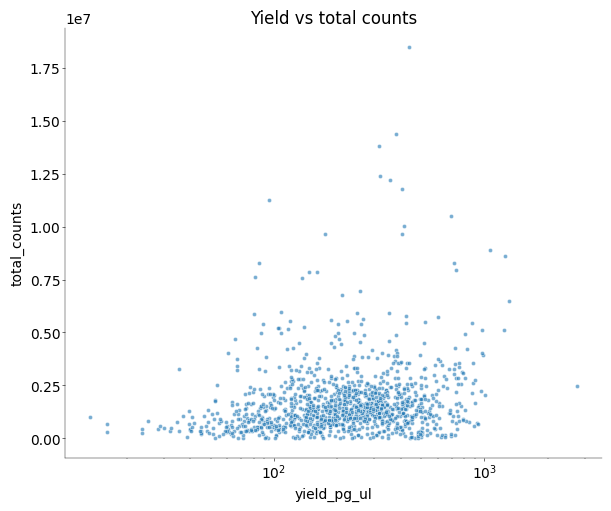

In [49]:
# Filter meta-data
meta_f = meta.loc[exclude_low_quality]

# build the initial per‑cell DataFrame
df_cell = pd.DataFrame(
    {
        "Cell": meta_f["Cell"],
        "total_counts": exonCounts.sum(axis=1),
        "n_genes": (exonCounts > 0).sum(axis=1),
        "rna_family": rna_family,
        "rna_type": rna_type,
        "layer": layers[exclude_low_quality],
        "cre_line": meta_f["Cre"],
        "batch": meta_f["Sequencing batch"],
        "yield_pg_ul": yields[exclude_low_quality],
        "depth_um": depth[exclude_low_quality],
        "thickness_um": thickness[exclude_low_quality],
        "traced": traced[exclude_low_quality],
        "mouse": meta_f["Mouse"],
    }
)
df_cell["mouse_age"] = df_cell["mouse"].map(mice_ages)
df_cell["mouse_cre"] = df_cell["mouse"].map(mice_cres)

# 1) Add mito_frac and ribo_frac
mito_mask = [g.lower().startswith("mt-") for g in genes]
df_cell["mito_frac"] = (
    exonCounts[:, mito_mask].sum(axis=1) / df_cell["total_counts"]
)

ribo_mask = [g.startswith(("Rpl", "Rps")) for g in genes]
df_cell["ribo_frac"] = (
    exonCounts[:, ribo_mask].sum(axis=1) / df_cell["total_counts"]
)

# 2) Compute per‑gene stats
gene_mean = exonCounts.mean(axis=0)
gene_var = exonCounts.var(axis=0, ddof=1)
gene_cv2 = gene_var / (gene_mean**2 + 1e-8)
gene_stats = pd.DataFrame(
    {
        "gene": genes,
        "mean": gene_mean,
        "variance": gene_var,
        "cv2": gene_cv2,
        "length": exonLengths,
    }
)

# 3) QC plots

# 3.1 Histograms of total_counts, n_genes, mito_frac, ribo_frac
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.histplot(df_cell["total_counts"], log_scale=(True, False), ax=axes[0, 0])
axes[0, 0].set_title("Total counts per cell")
sns.histplot(df_cell["n_genes"], ax=axes[0, 1])
axes[0, 1].set_title("Detected genes per cell")
sns.histplot(df_cell["mito_frac"], ax=axes[1, 0])
axes[1, 0].set_title("Mito fraction per cell")
sns.histplot(df_cell["ribo_frac"], ax=axes[1, 1])
axes[1, 1].set_title("Ribo fraction per cell")
plt.show()

top50_sum = np.sort(exonCounts, axis=1)[:, -50:].sum(axis=1)
df_cell["frac_top50"] = top50_sum / df_cell["total_counts"]

# b) Dropout rate: fraction of zero-count genes per cell
zero_counts = (exonCounts == 0).sum(axis=1)
n_genes_total = exonCounts.shape[1]
df_cell["dropout_rate"] = zero_counts / n_genes_total

# Quick histograms to inspect these new metrics:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_cell["frac_top50"], ax=ax[0])
ax[0].set_title("Fraction counts in top 50 genes")
sns.histplot(df_cell["dropout_rate"], ax=ax[1])
ax[1].set_title("Dropout rate (zeros per cell)")
plt.tight_layout()
plt.show()


# 3.2 Barcode‑rank plot
sorted_tot = np.sort(df_cell["total_counts"])[::-1]
plt.figure(figsize=(6, 4))
plt.loglog(sorted_tot, marker=".", linestyle="none")
plt.xlabel("Cell rank")
plt.ylabel("Total counts")
plt.title("Barcode‑rank plot")
plt.show()

# 3.3 Genes vs counts scatter colored by mito_frac
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x="total_counts",
    y="n_genes",
    hue="mito_frac",
    data=df_cell,
    palette="viridis",
    s=10,
    alpha=0.6,
)
plt.xscale("log")
plt.yscale("log")
plt.title("Genes detected vs total counts")
plt.show()

# 3.4 Counts by batch & Cre line
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.violinplot(x="batch", y="total_counts", data=df_cell, cut=0, ax=axes[0])
axes[0].tick_params(axis="x", rotation=90)
axes[0].set_title("Counts by sequencing batch")
sns.violinplot(x="cre_line", y="total_counts", data=df_cell, cut=0, ax=axes[1])
axes[1].tick_params(axis="x", rotation=90)
axes[1].set_title("Counts by Cre line")
plt.tight_layout()
plt.show()

# 3.5 Mean–variance scatter with Poisson reference
plt.figure(figsize=(6, 5))
x = np.log10(gene_stats["mean"] + 1e-6)
y = np.log10(gene_stats["variance"] + 1e-6)
plt.scatter(x, y, s=5, alpha=0.5)
lims = [min(x.min(), y.min()), max(x.max(), y.max())]
plt.plot(lims, lims, color="red", label="Poisson var=mean")
plt.xlabel("log10(mean)")
plt.ylabel("log10(var)")
plt.legend()
plt.title("Gene mean–variance")
plt.show()

# 4) Example gene distributions
for gene in ["Rplp0", "Gad1"]:
    if gene in genes:
        idx = np.where(genes == gene)[0][0]
        df_cell[f"log1p_{gene}"] = np.log1p(exonCounts[:, idx])
        plt.figure(figsize=(8, 4))
        sns.violinplot(x="rna_family", y=f"log1p_{gene}", data=df_cell, cut=0)
        plt.title(f"{gene} expression (log1p) by RNA family")
        plt.ylabel("log1p(count)")
        plt.xticks([], [])
        plt.show()

# 5) Label distributions & metadata checks
plt.figure(figsize=(6, 4))
df_cell["rna_family"].value_counts().plot.bar()
plt.title("RNA family distribution")
plt.ylabel("Cells")
plt.show()

plt.figure(figsize=(8, 4))
df_cell["rna_type"].value_counts().head(20).plot.bar()
plt.title("Top 20 RNA types")
plt.ylabel("Cells")
plt.show()

ct = pd.crosstab(df_cell["layer"], df_cell["rna_family"])
ct.div(ct.sum(1), axis=0).plot.bar(stacked=True, figsize=(8, 5))
plt.ylabel("Fraction")
plt.title("Layer vs RNA family")
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

# Yield vs library size
plt.figure(figsize=(6, 5))
sns.scatterplot(x="yield_pg_ul", y="total_counts", data=df_cell, alpha=0.6)
plt.xscale("log")
plt.title("Yield vs total counts")
plt.show()

### 1.2 - Electrophysiology

---
## 2 - Normalize & transform the data; select genes & apply PCA

There are several ways of normalizing the RNA count data (Raw, CPM, CPMedian, RPKM, see https://www.reneshbedre.com/blog/expression_units.html, https://translational-medicine.biomedcentral.com/articles/10.1186/s12967-021-02936-w). Take into account that there are certain normalizations that only make sense for UMI data, but not for this read count data. You also explored different transformations in the assignment (none, log, sqrt). Compare how the different transformations change the two-dimensional visualization. After normalization and transformation, choose a set of highly variable genes (as demonstrated in the lecture) and apply PCA. Play with the number of selected genes and the number of PCA components, and again compare their effects on the two-dimensional visualization.

In [19]:
# RUN THIS

# Encode RNA families for coloring
le = LabelEncoder()
fam_labels = le.fit_transform(rna_family)
fam_categories = le.classes_


# Normalization functions
def cpm_norm(counts):
    return counts / counts.sum(axis=1, keepdims=True) * 1e6


def deseq2_norm(counts, min_cells=3, eps=1e-8):

    # keep genes with some minimal expression
    gene_mask = (counts > 0).sum(axis=0) >= min_cells
    X = counts[:, gene_mask]
    # geometric mean of each kept gene across cells
    gm = np.exp(np.mean(np.log(X + eps), axis=0))
    # make sure gm is never zero
    gm[gm == 0] = np.nan

    # ratios for every cell / gene
    ratios = X / gm
    # size factor per cell = median of (non‑zero) ratios
    size_factors = np.nanmedian(ratios, axis=1)
    # guard against cells with all‑zero genes after filtering
    size_factors[np.isnan(size_factors) | (size_factors == 0)] = 1.0
    # divide original counts (not the subset) by its cell’s size factor
    return counts / size_factors[:, None]


counts_dict = {
    "raw": exonCounts.copy(),
    "CPM": cpm_norm(exonCounts),
    "DESeq2": deseq2_norm(exonCounts),
}

# Transformations
transforms = {
    "linear": lambda X: X,
    "sqrt": lambda X: np.sqrt(X),
    "log1p": lambda X: np.log1p(X),
}

# Pre-compute all normalized and transformed matrices
#    keys are tuples (norm_name, tfm_name)
transformed_data = {}
for norm_name, counts in counts_dict.items():
    for tfm_name, tfm in transforms.items():
        transformed_data[(norm_name, tfm_name)] = tfm(counts)


# HVG selection function
def select_hvg(X, n_top=2000, n_bins=20):
    """
    Manual HVG selection: bin by mean, z‑score dispersion within each bin.
    """
    mu = np.nanmean(X, axis=0)
    var = np.nanvar(X, axis=0, ddof=1)
    disp = var / (mu + 1e-12)

    # Bin genes by mean (dropping NaN means)
    valid = ~np.isnan(mu)
    bins = pd.qcut(mu[valid], q=n_bins, labels=False, duplicates="drop")
    disp_z = np.zeros_like(disp)
    for b in np.unique(bins):
        idx_b = np.where(valid)[0][bins == b]
        d_b = disp[idx_b]
        m, s = d_b.mean(), d_b.std(ddof=1)
        if s > 0:
            disp_z[idx_b] = (d_b - m) / s
        else:
            disp_z[idx_b] = 0.0

    # pick top
    n_select = min(n_top, disp_z.size)
    return np.argsort(disp_z)[-n_select:]


# PCA + Metrics
def run_pca_metrics(X, n_hvg=2000, n_pc=20):
    hvg_idx = select_hvg(X, n_hvg)
    X_hvg = X[:, hvg_idx]
    X_scaled = StandardScaler().fit_transform(X_hvg)
    pca = PCA(n_components=n_pc)
    pcs = pca.fit_transform(X_scaled)
    sil_score = silhouette_score(pcs[:, :2], fam_labels)
    return {
        "pcs": pcs,
        "var_ratio": pca.explained_variance_ratio_,
        "silhouette": sil_score,
    }


# Grid Search
hvg_sizes = [500, 1000, 2000, 5000]
n_pc_list = [10, 20, 50]

results = {}
for (norm_name, tfm_name), X_tfm in transformed_data.items():
    for n_hvg in hvg_sizes:
        for n_pc in n_pc_list:
            key = (norm_name, tfm_name, n_hvg, n_pc)
            results[key] = run_pca_metrics(X_tfm, n_hvg=n_hvg, n_pc=n_pc)

In [119]:
for key, val in transformed_data.items():
    if np.any(~np.isfinite(val)) or np.any(np.isnan(val)):
        print(key)

In [120]:
for key, val in results.items():
    if np.any(~np.isfinite(val["pcs"])) > 0 or np.any(np.isnan(val["pcs"])):
        print(key)

For Task 2, we made the following choices to ensure that our PCA reflects true biological variation rather than technical artifacts:

1. **Normalization**
   We use **DESeq2 size‑factor** normalization instead of simple CPM/RPKM/TPM because DESeq2 corrects not only for total read depth but also for compositional differences (i.e. when a few genes dominate the library). Zhao et al. (2021) showed that median‑of‑ratios (DESeq2) and TMM produce the lowest coefficient of variation and best clustering of biological replicates, whereas TPM/FPKM can be distorted by highly expressed genes. **CPM** is included only as a baseline check.

2. **Variance‑stabilising transformation**
   After normalization, counts remain skewed (many zeros, few very large values). We apply **$\log(1+x)$** (and compare to $\sqrt x$ or linear) because $\log$ compresses extremes and approximates normality, which makes PCA more meaningful. Square‑root is a milder alternative, and leaving the data untransformed reveals whether skew still dominates the PCs.

3. **Highly Variable Gene (HVG) selection**
   With tens of thousands of genes, most contribute only noise. We rank genes by their dispersion (variance/mean) across cells and select the top N (e.g. 2 000), focusing PCA on the features that drive real cell‑to‑cell differences.

4. **PCA on scaled HVGs**
   Finally, we z‑score each selected gene and run PCA (choosing 10, 20, or 50 components). By projecting onto the first two PCs, we get a 2D view where cells of the same annotated family/type should cluster tightly if normalization and transformation have succeeded in minimizing technical effects.

Each of these steps—robust normalization, log transform, HVG filtering, and PCA—builds on best practices for RNA‑seq visualization and is grounded in the evidence presented by Zhao et al.


---
## 3 - Two-dimensional visualization

To visualize the RNA count data after normalization, transformation, gene selection and PCA, try different methods (just PCA, t-SNE, UMAP, ..) and vary their parameters (exaggeration, perplexity, ..). Compare them using quantitative metrics (e.g., kNN accuracy in high-dim vs. two-dim, kNN recall). Please refer to Lause et al., 2024 (https://doi.org/10.1371/journal.pcbi.1012403) where many of these metrics are discussed and explained to make an informed choice on which metrics to use. Think about also using the electrophysiological features and other metadata to enhance different visualizations.

In [28]:
# --- 8) two‑dimensional embeddings & evaluation --------------------------------
warnings.filterwarnings(
    "ignore",
    message=".*'force_all_finite' was renamed to 'ensure_all_finite'.*",
    category=FutureWarning,
)

# 8.1) registry of embedding methods
embed_fns = {
    "PCA2D": lambda P, **kw: PCA(n_components=2, **kw).fit_transform(P),
    "tSNE": lambda P, **kw: TSNE(n_components=2, **kw).fit_transform(P),
    "UMAP": lambda P, **kw: umap.UMAP(n_components=2, **kw).fit_transform(P),
}

# 8.2) hyper‑parameter grid
embed_params = []
# PCA‑2D baseline
embed_params.append(("PCA2D", {}))

# t‑SNE sweep
for perp in [5]:  # [5, 10, 30, 50, 100]:
    for exag in [1]:  # [1, 4, 12]:
        embed_params.append(
            (
                "tSNE",
                {
                    "perplexity": perp,
                    "early_exaggeration": exag,
                    "learning_rate": "auto",
                    "init": "pca",
                    "random_state": 0,
                },
            )
        )

# UMAP sweep
for nnb in [5]:  # [5, 15, 30, 50]:
    for dist in [0.0]:  # [0.0, 0.1, 0.3, 0.5]:
        embed_params.append(
            (
                "UMAP",
                {
                    "n_neighbors": nnb,
                    "min_dist": dist,
                    "metric": "euclidean",
                    "random_state": 0,
                },
            )
        )


# 8.3) evaluation function for one 2D embedding
def evaluate_embedding(Y2d, labels, NN_hd, P_hd, k=10):
    # 2D neighbors
    NN_2d = (
        NearestNeighbors(n_neighbors=k)
        .fit(Y2d)
        .kneighbors(return_distance=False)
    )
    # kNN accuracy (label purity)
    preds = np.array([np.bincount(labels[nn]).argmax() for nn in NN_2d])
    knn_acc = (preds == labels).mean()
    # kNN recall (continuity)
    knn_recall = np.mean(
        [
            len(set(NN_hd[i]).intersection(NN_2d[i])) / k
            for i in range(len(labels))
        ]
    )
    # silhouette in 2D
    sil = silhouette_score(Y2d, labels)
    # trustworthiness
    trust = sk_trustworthiness(P_hd, Y2d, n_neighbors=k)
    # AMI via HDBSCAN
    clust = hdbscan.HDBSCAN(min_cluster_size=30).fit(Y2d)
    ami = adjusted_mutual_info_score(labels, clust.labels_)
    return dict(
        knn_acc=knn_acc,
        knn_recall=knn_recall,
        silhouette=sil,
        trust=trust,
        ami=ami,
    )


# 8.4) run embeddings & collect metrics
embedding_results = {}

# compute total number of runs
total_runs = len(results) * len(embed_params)
run_counter = 1

for key, pca_out in results.items():
    # pca_out['pcs'] is the HD representation of shape (n_cells, n_pc)
    P_hd = pca_out["pcs"]
    # precompute HD neighbor graph
    NN_hd = (
        NearestNeighbors(n_neighbors=10)
        .fit(P_hd)
        .kneighbors(return_distance=False)
    )

    for method, params in embed_params:
        print(
            f"[{run_counter}/{total_runs}] "
            f"Config={key} → Embedding={method}, params={params}"
        )

        # perform embedding
        Y2d = embed_fns[method](P_hd, **params)

        # evaluate
        metrics = evaluate_embedding(Y2d, fam_labels, NN_hd, P_hd, k=10)
        embedding_results[(key, method, tuple(sorted(params.items())))] = (
            metrics
        )

        print(
            f"    → Done: knn_acc={metrics['knn_acc']:.3f}, "
            f"knn_recall={metrics['knn_recall']:.3f}, "
            f"silhouette={metrics['silhouette']:.3f}, "
            f"trust={metrics['trust']:.3f}, ami={metrics['ami']:.3f}\n"
        )

        run_counter += 1

print("All embeddings evaluated.")

[1/216] Config=('raw', 'linear', 500, 10) → Embedding=PCA2D, params={}
    → Done: knn_acc=0.444, knn_recall=0.217, silhouette=-0.225, trust=0.852, ami=0.048

[2/216] Config=('raw', 'linear', 500, 10) → Embedding=tSNE, params={'perplexity': 5, 'early_exaggeration': 1, 'learning_rate': 'auto', 'init': 'pca', 'random_state': 0}
    → Done: knn_acc=0.731, knn_recall=0.576, silhouette=-0.101, trust=0.969, ami=0.367

[3/216] Config=('raw', 'linear', 500, 10) → Embedding=UMAP, params={'n_neighbors': 5, 'min_dist': 0.0, 'metric': 'euclidean', 'random_state': 0}


C:\Users\pdvsupport\anaconda3\envs\nds\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


    → Done: knn_acc=0.743, knn_recall=0.545, silhouette=-0.132, trust=0.964, ami=0.454

[4/216] Config=('raw', 'linear', 500, 20) → Embedding=PCA2D, params={}
    → Done: knn_acc=0.444, knn_recall=0.198, silhouette=-0.225, trust=0.836, ami=0.048

[5/216] Config=('raw', 'linear', 500, 20) → Embedding=tSNE, params={'perplexity': 5, 'early_exaggeration': 1, 'learning_rate': 'auto', 'init': 'pca', 'random_state': 0}
    → Done: knn_acc=0.777, knn_recall=0.536, silhouette=-0.102, trust=0.960, ami=0.031

[6/216] Config=('raw', 'linear', 500, 20) → Embedding=UMAP, params={'n_neighbors': 5, 'min_dist': 0.0, 'metric': 'euclidean', 'random_state': 0}


C:\Users\pdvsupport\anaconda3\envs\nds\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


    → Done: knn_acc=0.764, knn_recall=0.505, silhouette=-0.067, trust=0.952, ami=0.382

[7/216] Config=('raw', 'linear', 500, 50) → Embedding=PCA2D, params={}
    → Done: knn_acc=0.444, knn_recall=0.161, silhouette=-0.225, trust=0.793, ami=0.048

[8/216] Config=('raw', 'linear', 500, 50) → Embedding=tSNE, params={'perplexity': 5, 'early_exaggeration': 1, 'learning_rate': 'auto', 'init': 'pca', 'random_state': 0}
    → Done: knn_acc=0.792, knn_recall=0.481, silhouette=-0.119, trust=0.927, ami=0.352

[9/216] Config=('raw', 'linear', 500, 50) → Embedding=UMAP, params={'n_neighbors': 5, 'min_dist': 0.0, 'metric': 'euclidean', 'random_state': 0}


...

    → Done: knn_acc=0.890, knn_recall=0.542, silhouette=0.220, trust=0.979, ami=0.720

[211/216] Config=('CPM', 'log1p', 5000, 20) → Embedding=PCA2D, params={}
    → Done: knn_acc=0.515, knn_recall=0.129, silhouette=-0.147, trust=0.786, ami=0.260

[212/216] Config=('CPM', 'log1p', 5000, 20) → Embedding=tSNE, params={'perplexity': 5, 'early_exaggeration': 1, 'learning_rate': 'auto', 'init': 'pca', 'random_state': 0}
    → Done: knn_acc=0.939, knn_recall=0.548, silhouette=0.086, trust=0.974, ami=0.581

[213/216] Config=('CPM', 'log1p', 5000, 20) → Embedding=UMAP, params={'n_neighbors': 5, 'min_dist': 0.0, 'metric': 'euclidean', 'random_state': 0}


C:\Users\pdvsupport\anaconda3\envs\nds\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


    → Done: knn_acc=0.933, knn_recall=0.507, silhouette=0.413, trust=0.967, ami=0.774

[214/216] Config=('CPM', 'log1p', 5000, 50) → Embedding=PCA2D, params={}
    → Done: knn_acc=0.515, knn_recall=0.102, silhouette=-0.147, trust=0.727, ami=0.260

[215/216] Config=('CPM', 'log1p', 5000, 50) → Embedding=tSNE, params={'perplexity': 5, 'early_exaggeration': 1, 'learning_rate': 'auto', 'init': 'pca', 'random_state': 0}
    → Done: knn_acc=0.930, knn_recall=0.464, silhouette=0.096, trust=0.923, ami=0.613

[216/216] Config=('CPM', 'log1p', 5000, 50) → Embedding=UMAP, params={'n_neighbors': 5, 'min_dist': 0.0, 'metric': 'euclidean', 'random_state': 0}


C:\Users\pdvsupport\anaconda3\envs\nds\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


    → Done: knn_acc=0.933, knn_recall=0.423, silhouette=0.311, trust=0.911, ami=0.726

All embeddings evaluated.
  norm    tfm  n_hvg  n_pc method   knn_acc  knn_recall  silhouette     trust  \
0  CPM   sqrt   5000    10   UMAP  0.922890    0.553247    0.256758  0.986841   
1  CPM   sqrt   2000    10   UMAP  0.917208    0.550568    0.238748  0.986145   
2  CPM   sqrt   1000    10   UMAP  0.913961    0.535633    0.341451  0.983780   
3  CPM   sqrt   2000    20   UMAP  0.932630    0.533847    0.276718  0.981343   
4  CPM  log1p   2000    10   UMAP  0.931818    0.520617    0.338559  0.982841   
5  raw  log1p   5000    20   UMAP  0.936688    0.534334    0.248550  0.974657   
6  CPM   sqrt   2000    10   tSNE  0.922078    0.571266    0.110837  0.986500   
7  CPM   sqrt   1000    20   UMAP  0.918019    0.514123    0.404472  0.979319   
8  CPM   sqrt   5000    10   tSNE  0.929383    0.588231    0.097472  0.987781   
9  CPM  log1p   5000    20   UMAP  0.933442    0.506656    0.413345  0.966597

In [37]:
rows = []
for (norm, tfm, n_hvg, n_pc), method, params_tuple in embedding_results.keys():
    # collect the metric dict
    met = embedding_results[(norm, tfm, n_hvg, n_pc), method, params_tuple]
    rows.append(
        {
            "norm": norm,
            "tfm": tfm,
            "n_hvg": n_hvg,
            "n_pc": n_pc,
            "method": method,
            "params": dict(params_tuple),
            **met,
        }
    )

df_embed = pd.DataFrame(rows)

# rank each metric (higher better) and add mean rank
for col in ["knn_acc", "knn_recall", "silhouette", "trust", "ami"]:
    df_embed[f"{col}_rank"] = df_embed[col].rank(ascending=False)
df_embed["mean_rank"] = df_embed[
    [c for c in df_embed.columns if c.endswith("_rank")]
].mean(axis=1)

# final sorted table
df_embed = df_embed.sort_values("mean_rank").reset_index(drop=True)

df_embed.head(5)

,norm,tfm,n_hvg,n_pc,method,params,knn_acc,knn_recall,silhouette,trust,ami,knn_acc_rank,knn_recall_rank,silhouette_rank,trust_rank,ami_rank,mean_rank
0,CPM,sqrt,5000,10,UMAP,"{'metric': 'euclidean', 'min_dist': 0.0, 'n_ne...",0.922890,0.553247,0.256758,0.986841,0.640042,27.0,30.5,23.0,2.0,25.0,21.5
1,CPM,sqrt,2000,10,UMAP,"{'metric': 'euclidean', 'min_dist': 0.0, 'n_ne...",0.917208,0.550568,0.238748,0.986145,0.707046,39.0,35.0,25.0,5.0,16.0,24.0
2,CPM,sqrt,1000,10,UMAP,"{'metric': 'euclidean', 'min_dist': 0.0, 'n_ne...",0.913961,0.535633,0.341451,0.983780,0.750531,45.0,53.0,8.0,15.0,4.0,25.0
3,CPM,sqrt,2000,20,UMAP,"{'metric': 'euclidean', 'min_dist': 0.0, 'n_ne...",0.932630,0.533847,0.276718,0.981343,0.661632,12.5,56.0,18.0,29.0,24.0,27.9
4,CPM,log1p,2000,10,UMAP,"{'metric': 'euclidean', 'min_dist': 0.0, 'n_ne...",0.931818,0.520617,0.338559,0.982841,0.627463,14.5,71.0,10.0,20.0,30.0,29.1



=== Embedding Rank #1 ===
norm = 'CPM'
transform = 'sqrt'
n_hvg = 5000, n_pc = 10
method = UMAP
params = {'metric': 'euclidean', 'min_dist': 0.0, 'n_neighbors': 5, 'random_state': 0}



C:\Users\pdvsupport\anaconda3\envs\nds\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


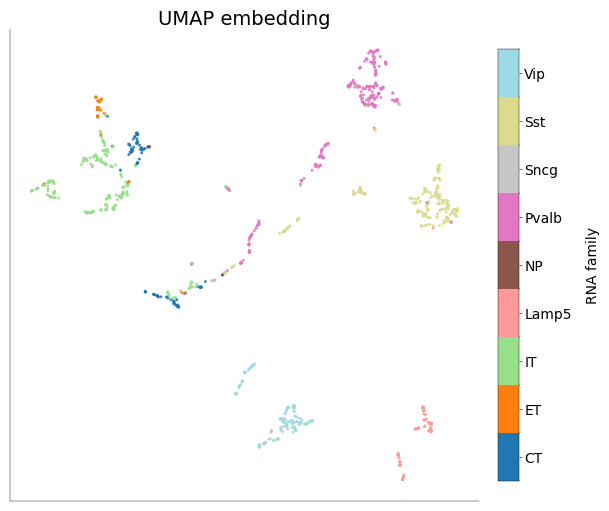


=== Embedding Rank #2 ===
norm = 'CPM'
transform = 'sqrt'
n_hvg = 2000, n_pc = 10
method = UMAP
params = {'metric': 'euclidean', 'min_dist': 0.0, 'n_neighbors': 5, 'random_state': 0}



C:\Users\pdvsupport\anaconda3\envs\nds\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


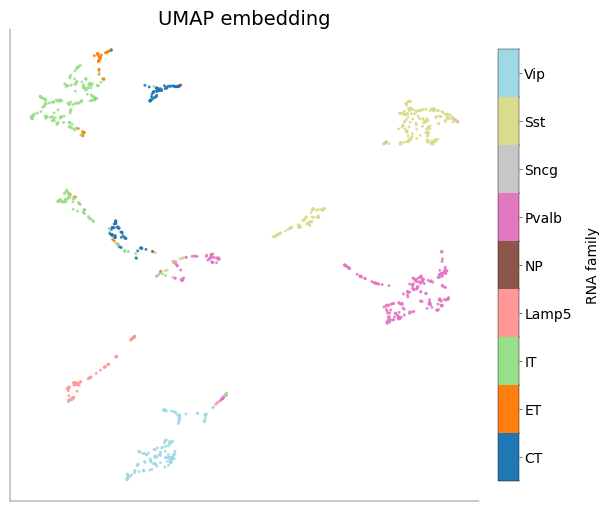


=== Embedding Rank #3 ===
norm = 'CPM'
transform = 'sqrt'
n_hvg = 1000, n_pc = 10
method = UMAP
params = {'metric': 'euclidean', 'min_dist': 0.0, 'n_neighbors': 5, 'random_state': 0}



C:\Users\pdvsupport\anaconda3\envs\nds\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


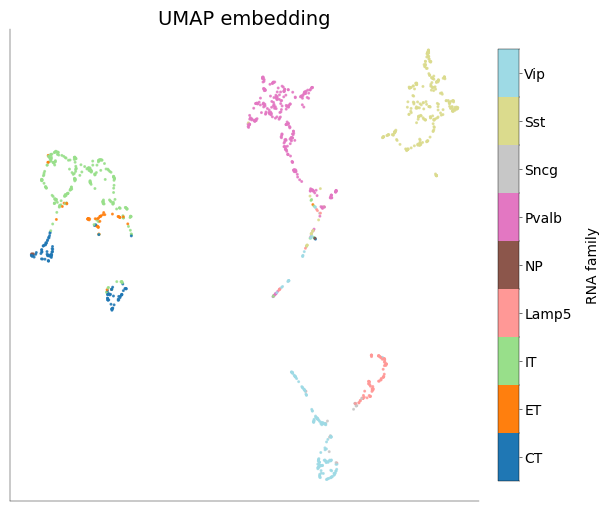


=== Embedding Rank #4 ===
norm = 'CPM'
transform = 'sqrt'
n_hvg = 2000, n_pc = 20
method = UMAP
params = {'metric': 'euclidean', 'min_dist': 0.0, 'n_neighbors': 5, 'random_state': 0}



C:\Users\pdvsupport\anaconda3\envs\nds\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


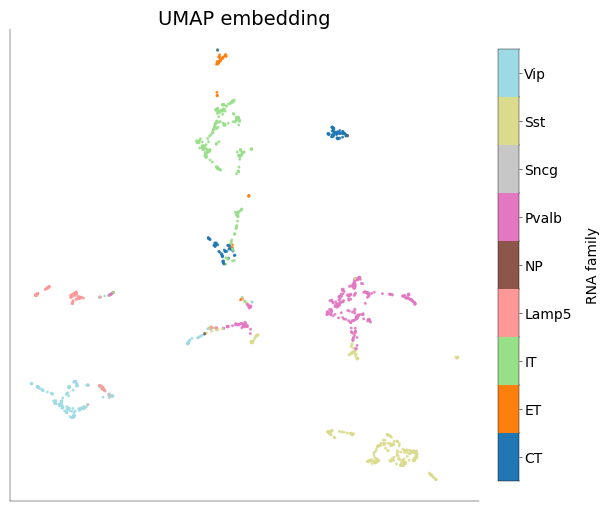


=== Embedding Rank #5 ===
norm = 'CPM'
transform = 'log1p'
n_hvg = 2000, n_pc = 10
method = UMAP
params = {'metric': 'euclidean', 'min_dist': 0.0, 'n_neighbors': 5, 'random_state': 0}



C:\Users\pdvsupport\anaconda3\envs\nds\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


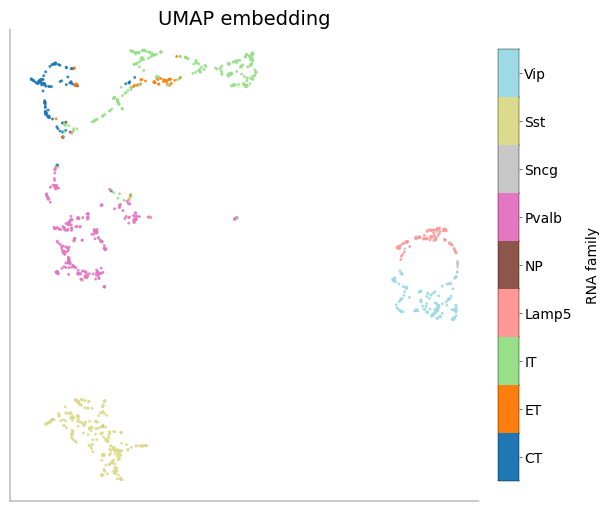

In [36]:


# how many categories?
n_cats = len(fam_categories)

# discrete colormap + norm
cmap = plt.get_cmap("tab20", n_cats)
norm = mcolors.BoundaryNorm(
    boundaries=np.arange(-0.5, n_cats + 0.5, 1), ncolors=n_cats
)

top_n = 5
top_df = df_embed.head(top_n)

for rank, (_, row) in enumerate(top_df.iterrows(), start=1):
    # 1) print all the info
    print(f"\n=== Embedding Rank #{rank} ===")
    print(f"norm = {row['norm']!r}")
    print(f"transform = {row['tfm']!r}")
    print(f"n_hvg = {row['n_hvg']}, n_pc = {row['n_pc']}")
    print(f"method = {row['method']}")
    print(f"params = {row['params']}\n")

    # 2) recover the high‑dim PCs and compute 2D embedding
    key = (row["norm"], row["tfm"], row["n_hvg"], row["n_pc"])
    P_hd = results[key]["pcs"]
    Y2d = embed_fns[row["method"]](P_hd, **row["params"])

    # 3) fresh figure + scatter
    fig, ax = plt.subplots(figsize=(6, 5))
    sc = ax.scatter(
        Y2d[:, 0],
        Y2d[:, 1],
        c=fam_labels,
        cmap=cmap,
        norm=norm,
        s=5,
        alpha=0.8,
    )
    ax.set_title(f"{row['method']} embedding", fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])

    # 4) discrete colorbar with family names
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # no actual data needed
    cbar = fig.colorbar(
        sm, ax=ax, ticks=np.arange(n_cats), fraction=0.046, pad=0.04
    )
    cbar.ax.set_yticklabels(fam_categories)
    cbar.set_label("RNA family", rotation=90, labelpad=10)

    plt.show()

Having completed normalization, transformation, variable‑gene selection and PCA (Task 2), we now face the challenge of **displaying** our high‑dimensional transcriptomic space in two dimensions. Traditionally, inspection of scatterplots is done by eye, looking for islands of cell types, but with dozens of preprocessing variants and embedding hyperparameters, visual inspection alone is neither scalable nor objective. We therefore automate a **quantitative search** for the best 2‑D map, using the metrics and recommendations from Lause *et al.* (2024) .

**1. Embedding methods under consideration**

* **PCA‑2D**: a linear baseline projecting directly onto the first two principal components.
* **t‑SNE**: preserves local neighborhoods via pairwise affinities; key hyperparameters include *perplexity* and *early exaggeration*.
* **UMAP**: balances local and global structure by approximating a Riemannian manifold; varied by *n\_neighbors* and *min\_dist*.

By sweeping each method over a grid of recommended hyperparameters, we generate a diverse set of candidate embeddings.

**2. Objective evaluation metrics**

**Lause *et al.* (2024)** systematically compare embeddings using metrics that capture both **neighborhood fidelity** and **cluster structure**. We adopt their core set, plus a complementary cluster‐agreement score:

1. **k‑NN accuracy**
   Fraction of each cell’s *k* nearest neighbors in 2D that share the same RNA‑family label—i.e. local label purity .
2. **k‑NN recall** (a.k.a. *continuity*)
   Fraction of a cell’s *k* neighbors in the high‑dimensional (PCA) space that remain neighbors in 2D.
3. **Silhouette coefficient**
   Measures how well cells of the same label form compact, separated clusters in the 2D layout.
4. **Trustworthiness**
   Penalizes “false” 2D neighbors that were not close in the original high‑dimensional space; computed as in Lee & Verleysen (2009) .
5. **Adjusted Mutual Information (AMI)**
   Agreement between an *unsupervised* clustering of the 2D map (e.g. HDBSCAN) and the RNA‑family labels.

By combining **label‑dependent** (1, 3, 5) and **label‑independent** (2, 4) criteria, we guard against “over‑fitting” to potentially noisy annotations while still rewarding clear, biologically meaningful separations.

**3. Workflow outline**

1. **Reference space freeze**
   Choose one normalized & transformed gene set (e.g. top 2000 HVGs, 50 PCs) and compute its *k*‑NN graph once.
2. **Grid generation**
   For each embedding method, iterate over its hyperparameter grid to produce 2D coordinates.
3. **Metric computation**
   For every 2D map, compute the five metrics above, using the frozen high‑dimensional graph for continuity/trustworthiness.
4. **Aggregate & rank**
   Either rank each embedding on each metric and compute a mean rank, or normalize metrics to \[0, 1] and form a weighted sum.
5. **Select winner**
   The top‑ranked embedding provides an objective choice for visualization, reproducing Lause *et al.*’s finding that properly‑tuned t‑SNE/UMAP often dramatically outperform PCA‑2D in local purity and cluster separation .


By following this **principled, metric‑driven** pipeline, we obtain a reproducible, defensible choice of 2D projection.


In [123]:
def get_top_unique_datasets(df_embed, top_n):
    top = df_embed.head(top_n)
    seen = set()
    unique = []
    for _, row in top.iterrows():
        ds = (row["norm"], row["tfm"], row["n_hvg"], row["n_pc"])
        if ds not in seen:
            seen.add(ds)
            unique.append(ds)
    print(f"From top {top_n} embeddings → {len(unique)} unique datasets")
    for ds in unique:
        print(f"  • {ds}")
    return unique


def fetch_dataset_matrices(df_embed, transformed_data, results, top_n=10):
    """
    Returns a dict:
      { (norm,tfm,n_hvg,n_pc): { 'X_tfm':…, 'P_hd':… }, … }
    for the first top_n ranked embeddings (deduped by dataset).
    """
    unique_ds = get_top_unique_datasets(df_embed, top_n)
    ds_data = {}
    for ds in unique_ds:
        norm, tfm, n_hvg, n_pc = ds

        # your normalized+transformed counts
        X_tfm = transformed_data[(norm, tfm)]

        # the PCA‐scores (n_cells × n_pc)
        P_hd = results[(norm, tfm, n_hvg, n_pc)]["pcs"]

        ds_data[ds] = {"X_tfm": X_tfm, "P_hd": P_hd}
    return ds_data


# — example usage —
unique_ds_data = fetch_dataset_matrices(
    df_embed, transformed_data, results, top_n=10
)

From top 10 embeddings → 8 unique datasets
  • ('CPM', 'sqrt', 5000, 10)
  • ('CPM', 'sqrt', 2000, 10)
  • ('CPM', 'sqrt', 1000, 10)
  • ('CPM', 'sqrt', 2000, 20)
  • ('CPM', 'log1p', 2000, 10)
  • ('raw', 'log1p', 5000, 20)
  • ('CPM', 'sqrt', 1000, 20)
  • ('CPM', 'log1p', 5000, 20)


In [21]:
# RUN THIS
dataset_lst = [
    ("CPM", "sqrt", 5000, 10),
    ("CPM", "sqrt", 2000, 10),
    ("CPM", "sqrt", 1000, 10),
    ("CPM", "sqrt", 2000, 20),
    ("CPM", "log1p", 2000, 10),
    ("raw", "log1p", 5000, 20),
    ("CPM", "sqrt", 1000, 20),
    ("CPM", "log1p", 5000, 20),
]

unique_ds_data = {}

for ds in dataset_lst:
    norm, tfm, n_hvg, n_pc = ds

    # your normalized+transformed counts
    X_tfm = transformed_data[(norm, tfm)]

    # the PCA‐scores (n_cells × n_pc)
    P_hd = results[(norm, tfm, n_hvg, n_pc)]["pcs"]

    unique_ds_data[ds] = {"X_tfm": X_tfm, "P_hd": P_hd}

---
# 4 - Clustering
To find cell types in the RNA count data, you will need to look for clusters. Try different clustering methods (leiden, GMM). Implement a negative binomial mixture model. For that you can follow a similar method that what is described in Harris et al. 2018 (https://journals.plos.org/plosbiology/article?id=10.1371/journal.pbio.2006387#abstract0), with fixed r (r=2). Feel free to simplify the setup from the paper and not optimize over the set of important genes S but fix it instead, or skip the split and merge part of their clustering algorithm. A vanilla NBMM implementation should suffice. Take into account that the NBMM tries to cluster data that follows a negative binomial distribution. Therefore, it does not make sense to apply this clustering method to all kinds of normalized and transformed data. Please refer to the Harris et al. 2018 publication for the appropriate choice of normalization, and reflect on why this normalization makes sense. Evaluate your clustering results (metrics, compare number of clusters to original labels,...).

---
# 5- Correlation between electrophysiological features and genes/PCs

Finally, connect RNA counts and functional data: Most likely, there will be interesting relationships between the transcriptomic and electrophyiological features in this data. Find these correlations and a way of visualizing them. In studying correlations using the PCA-reduced version of the transcriptomics data, it could be interesting to study PC loadings to see which genes are dominating which PCs. For other advanced analyses, you can get inspitation from Kobak et al., 2021 (https://doi.org/10.1111/rssc.12494).